In [1]:
import pandas as pd

In [2]:
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv(r"C:\Users\prabh\Downloads\Titanic.csv")
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [4]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

### Dropping Irrelevant Columns
The Cabin column was removed because it contains a large number of missing values. Keeping highly incomplete columns can negatively affect analysis quality. Removing irrelevant features simplifies the dataset and improves clarity.

In [5]:
df.drop("Cabin", axis=1, inplace=True)

### Handling Missing Values (Age)
Missing values in the Age column were replaced using mean imputation. This ensures that no data is lost while maintaining the overall distribution of the dataset. Imputation helps improve analysis accuracy and prevents errors during visualization and aggregation.

In [10]:
df["Age"] = df["Age"].fillna(df["Age"].mean())

### Family Size
A new feature called FamilySize was created by combining SibSp and Parch. This represents the total number of family members traveling together. Feature engineering helps uncover deeper patterns in the dataset.

In [11]:
df["FamilySize"] = df["SibSp"] + df["Parch"] + 1

### Age Groups
Passengers were categorized into age groups using binning. This allows better comparison of survival trends across different age categories. Grouping continuous variables helps improve interpretability.

In [12]:
df["AgeGroup"] = pd.cut(
    df["Age"],
    bins=[0,12,18,35,60,100],
    labels=["Child","Teen","Young Adult","Adult","Senior"]
)

### Survival Rate by Age Group
The survival rate was calculated for each age group using groupby and mean aggregation. The results show that survival probability varies across different age categories. Younger passengers generally had higher survival chances.

In [13]:
df.groupby("AgeGroup")["Survived"].mean()

C:\Users\prabh\AppData\Local\Temp\ipykernel_5956\2602041343.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("AgeGroup")["Survived"].mean()


AgeGroup
Child          0.579710
Teen           0.428571
Young Adult    0.353271
Adult          0.400000
Senior         0.227273
Name: Survived, dtype: float64

### Survival Rate by Embarkation Port
Survival rates were compared based on embarkation ports. The results indicate that passenger origin influenced survival probability. Certain ports show higher survival rates than others.

In [16]:
df.groupby("Embarked")["Survived"].mean()

Embarked
C    0.553571
Q    0.389610
S    0.336957
Name: Survived, dtype: float64

### Survival Rate by Family Size
Survival probability was analyzed based on family size. Passengers traveling alone or in small families showed different survival trends compared to large families. Family size appears to influence survival chances.

In [17]:
df.groupby("FamilySize")["Survived"].mean()

FamilySize
1     0.303538
2     0.552795
3     0.578431
4     0.724138
5     0.200000
6     0.136364
7     0.333333
8     0.000000
11    0.000000
Name: Survived, dtype: float64

### Age Distribution
The histogram shows the distribution of passenger ages. Most passengers fall within the young adult and adult categories. Understanding age distribution helps interpret survival trends.

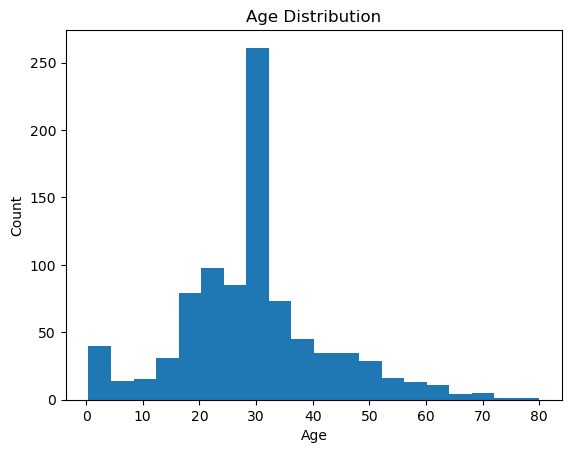

In [18]:
plt.hist(df["Age"], bins=20)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()

In [19]:
import seaborn as sns

### Correlation Analysis
The heatmap visualizes relationships between numerical variables. Pclass shows a negative correlation with survival. Fare shows a positive correlation with survival. The heatmap helps identify important predictive features.

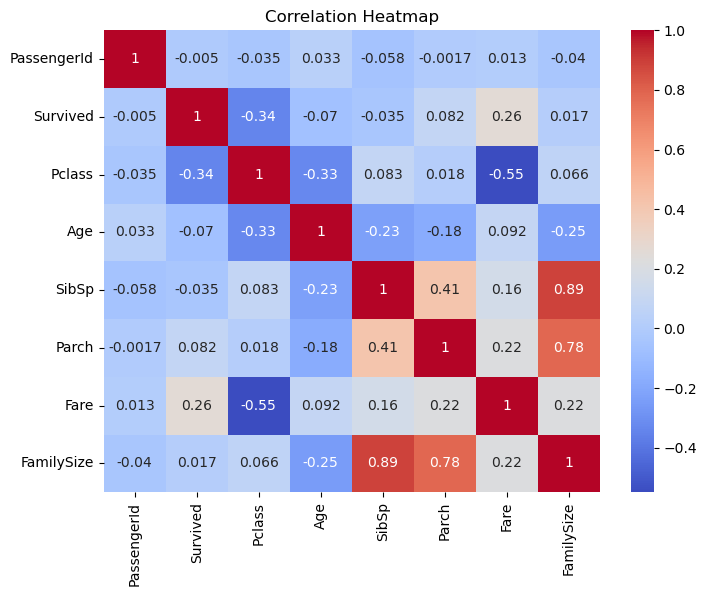

In [20]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()